Using Rioxarray to process Sentinel-2 data  - Mulitple Bands - v1 

## Table of Contents

1. [Import libraries](#1)<br>
2. [Read images](#2)<br>
3. [Subset](#3)<br>
    
</div>
<hr>

In [5]:
# Import necessary packages
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import mapping
# Use geopandas for vector data and xarray for raster data
import geopandas as gpd
import xarray as xr
import rioxarray as rxr

import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep


# Prettier plotting with seaborn
sns.set(font_scale=1.5, style="white")

## Read and subset one band 

In [2]:
# Load vector layer 
from geodatasets import get_path
path_to_file = get_path('nybb')
nybb = gpd.read_file(path_to_data)
## subsetting
def getsingleband(pth):
    band = rxr.open_rasterio(pth, masked=True)
    band_clipped = band.rio.clip(nybb.geometry.apply(mapping), nybb.crs)
    return band_clipped


C:\Users\Wenge\AppData\Local\Temp\ipykernel_38448\1743967971.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'nybb' data from the geodatasets package.

from geodatasets import get_path
path_to_file = get_path('nybb')

  path_to_data = gpd.datasets.get_path("nybb")


In [6]:
l = []
dirpath = r'C:\Users\Wenge\Dropbox (Hunter College)\data\EDS2022F\NYCimg\Sentinel-2\IMG_DATA'
pth= os.path.join(dirpath,'T18TWL_20210912T154911_B02.jp2')
l.append(getsingleband(pth))
pth= os.path.join(dirpath,'T18TWL_20210912T154911_B03.jp2')
l.append(getsingleband(pth))
pth= os.path.join(dirpath,'T18TWL_20210912T154911_B04.jp2')
l.append(getsingleband(pth))
pth= os.path.join(dirpath,'T18TWL_20210912T154911_B08.jp2')
l.append(getsingleband(pth))

In [8]:
#  Turn list of bands into a single xarray object    
bands_10m = xr.concat(l, dim="band") 
bands_10m

<xarray.DataArray (band: 4, y: 3973, x: 4300)>
array([[[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan, 1363., 1269., ...,   nan,   nan,   nan],
        [1277., 1313., 1241., ...,   nan,   nan,   nan],
        [1278., 1259., 1238., ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan, 1139., 1103., ...,   nan,   nan,   nan],
        [1085., 1133., 1069., ...,   nan,   nan,   nan],
        [1079., 1066., 1069., ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan, 1098.,  840., ...,   nan,   nan,   nan],
        [ 934., 1010.,  781., ...,   nan,   nan,   nan],
        [ 907.,  865.,  771., ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan, 1476., 2064., ...,   nan,   nan,   nan],
        [1127., 1825., 2231., ...,   nan,   nan,   nan],
        [1525., 2026., 2190., ...,   nan,   nan,   nan]]], dtype=float32)
Coordinates:
  * band         (band) int32 1 1 1 1
  * x            (x) float64 5.668e+05 5.668e+05 ... 6.097e+05 6.098e+05
  * y            (y) float64 4.53e+06 4.53e+06 4.53e+06 ... 4.49e+06 4.49e+06
    spatial_ref  int32 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [9]:
# View the Coordinate Reference System (CRS) & spatial extent
print("The CRS for this data is:", bands_10m.rio.crs)
print("The spatial extent is:", bands_10m.rio.bounds())
# View no data value
print("The no data value is:", bands_10m.rio.nodata)

The CRS for this data is: EPSG:32618
The spatial extent is: (566760.0, 4490220.0, 609760.0, 4529950.0)
The no data value is: None


In [10]:
print("the minimum raster value is: ", np.nanmin(bands_10m.values))
print("the maximum raster value is: ", np.nanmax(bands_10m.values))

the minimum raster value is:  0.0
the maximum raster value is:  24979.0


(<Figure size 1200x1200 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

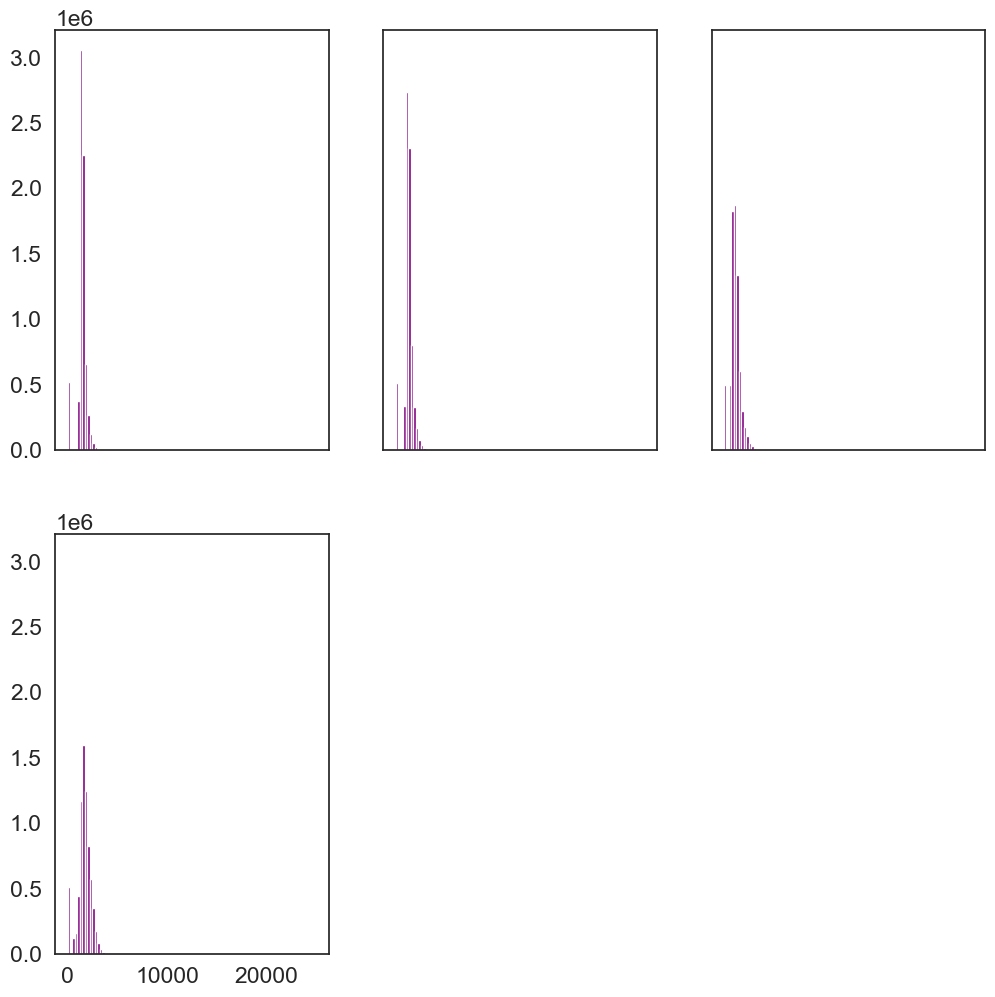

In [17]:
#ep.hist(bands_10m.values)
ep.hist(bands_10m.values, bins=100, cols=3)

In [21]:
type(bands_10m)

xarray.core.dataarray.DataArray

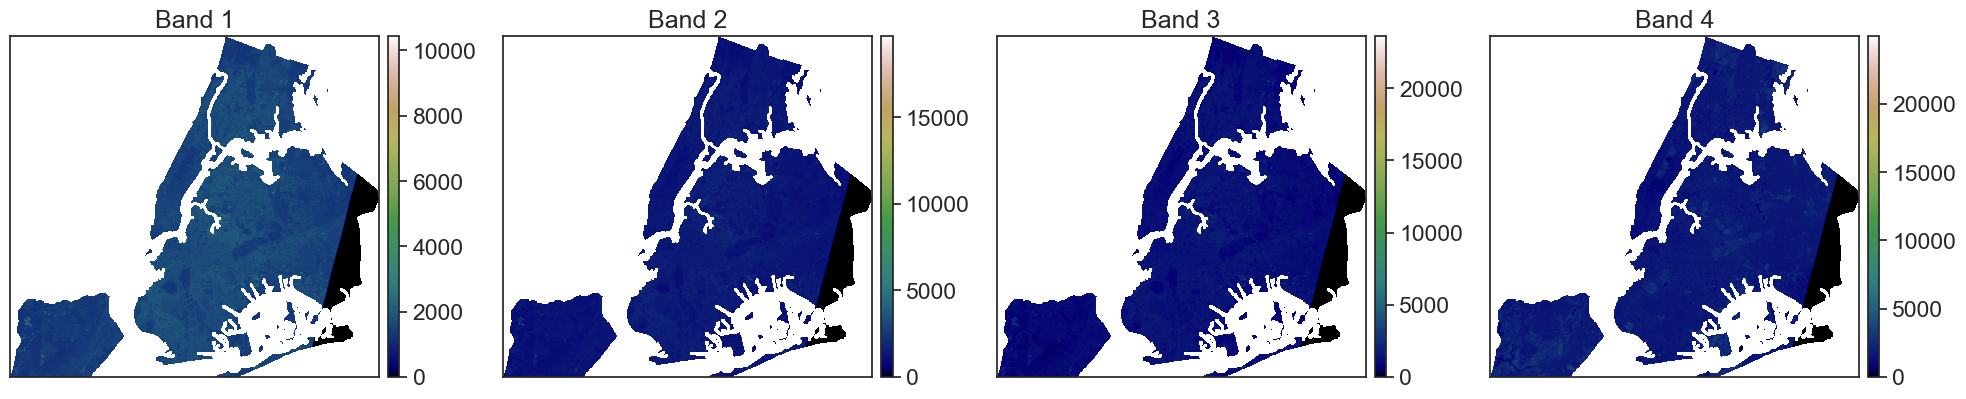

In [20]:
ep.plot_bands(bands_10m.values, 
              cmap = 'gist_earth', 
              figsize = (20, 12), 
              cols = 4, 
              cbar = True)
plt.show()

C:\Users\Wenge\miniconda3\envs\geospatial\lib\site-packages\earthpy\spatial.py:561: RuntimeWarning: invalid value encountered in cast
  return (bytedata.clip(low, high) + 0.5).astype("uint8")


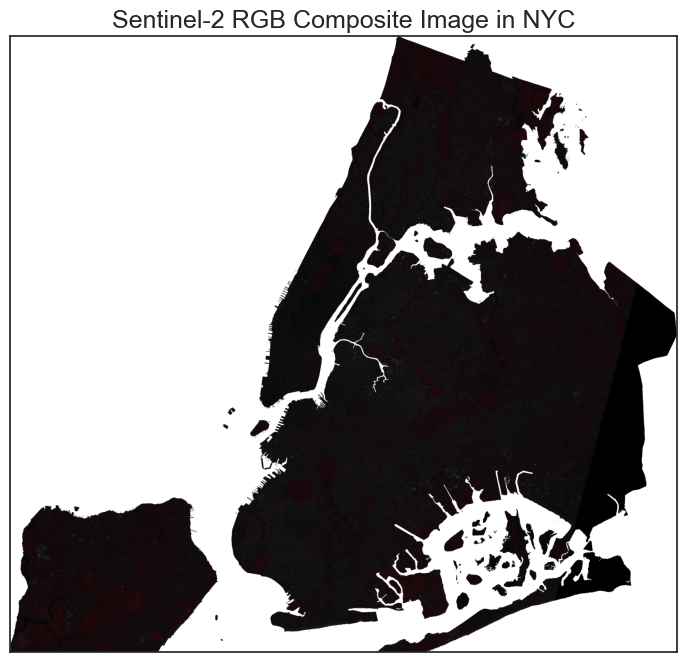

In [21]:
ep.plot_rgb(bands_10m.values, figsize = (10, 8),
            rgb=[3, 2, 1],
            title="Sentinel-2 RGB Composite Image in NYC")
plt.show()

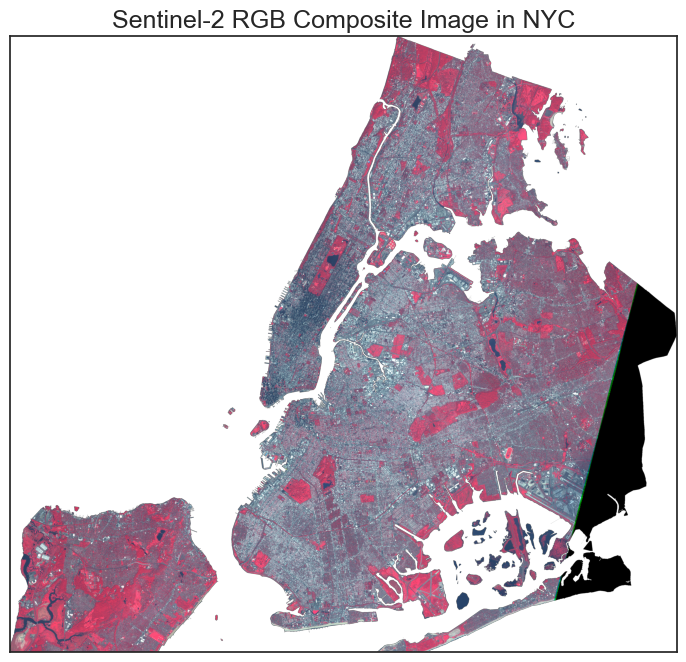

In [23]:
# Band stretching
ep.plot_rgb(bands_10m.values, figsize = (10, 8),
            rgb=[3, 2, 1], stretch = True, str_clip =1,
            title="Sentinel-2 RGB Composite Image in NYC")
plt.show()

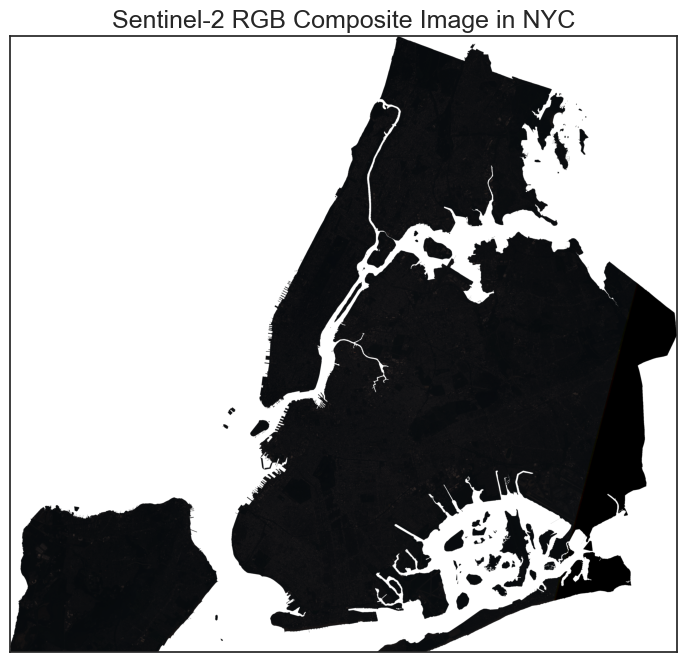

In [24]:
ep.plot_rgb(bands_10m.values,figsize = (10, 8),
            rgb=[2, 1,0],
            title="Sentinel-2 RGB Composite Image in NYC")
plt.show()

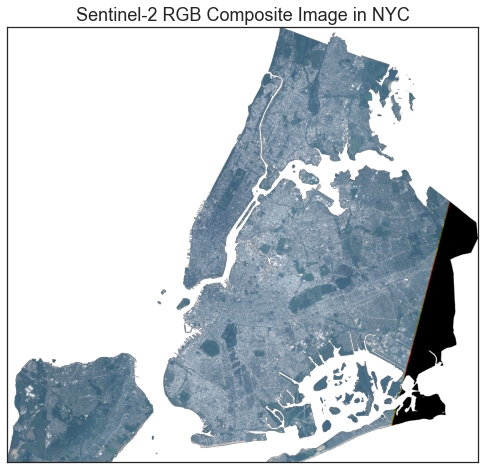

In [14]:
# Band stretching
ep.plot_rgb(bands_10m.values,figsize = (10, 8),
            rgb=[2, 1,0],stretch=True, str_clip = 1,
            title="Sentinel-2 RGB Composite Image in NYC")
plt.show()

<xarray.DataArray ()>
array(1., dtype=float32)
Coordinates:
    band         int32 1
    spatial_ref  int32 0


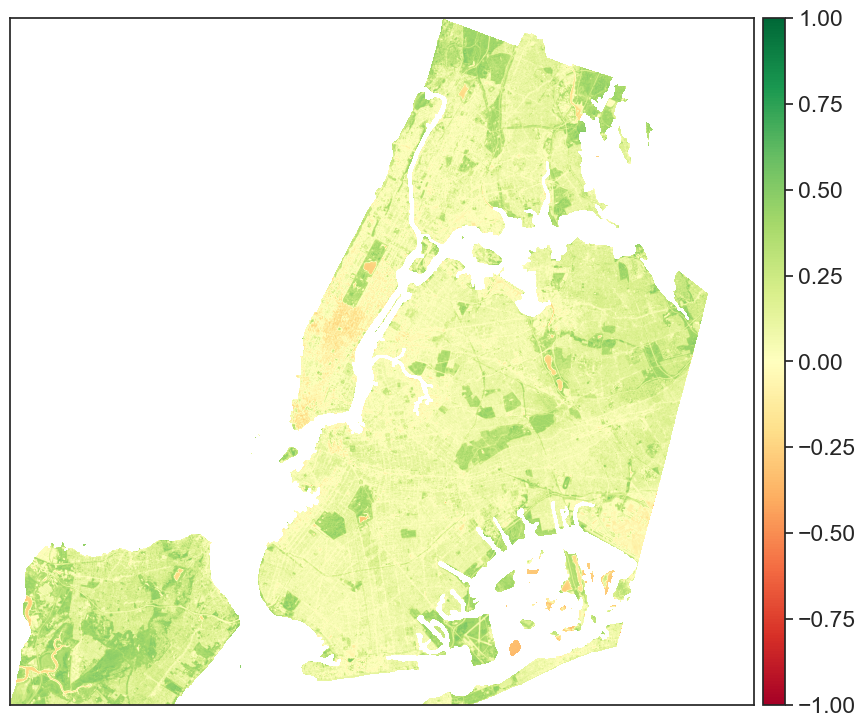

<Axes: >

In [25]:
#calculate NDVI using rioxarray
nir = bands_10m[3]
red = bands_10m[1]
ndvi = (nir-red)/(nir+red)
print(ndvi.max())
#ndvi.plot()
ep.plot_bands(ndvi, cmap="RdYlGn", scale=False, cols=1, vmin=-1, vmax=1, figsize=(10, 14))